# Machine Learning Basics I: The Classification Problem

files needed = ('iris.csv', 'diabetes.csv')

The next two notebooks introduce some concepts from machine learning. The theory behind a lot of this stuff is fairly complex, but much of the hard stuff is now wrapped up in packages we can use in python. Our goal here is not to create androids for Westworld, but just to get a sense of what "ML" is about. If you like these topics, you might try taking a machine learning course or working through some of the thousands of machine learning tutorials on the web.

In our discussions of machine learning, we will shift away from problems of *causal inference* and toward problems of *outcome prediction*. When we are trying to predict something that can only take a discrete number of values, we call it a classification problem. For example, we could try to classify a movie's genre: action, comedy, romance, or drama. Every movie has to be one of those four types. We would try to predict the movie's type using characteristics of the movie that we can observe: cast, running time, title, director, and movie studio. 

To create the classifier model, we need some data where we know both the movie genre and the movie characteristics. (Machine learning types would call a characteristic a "feature", and the genre the "class.") We call this the *training data.* We use the training data to create the model. Once we have the model, we use a second set of data that also has both the genres and the characteristics. This is the *testing data*. We give our model the characteristics and let it predict the genre. We then compare the predicted genre to the actual genre and measure how well our model performed.

Once we are happy with our model (it predicts well in the testing data), we can use the model to predict the genre of any movie, given the movie's characteristics. 

We are going to use the *scikit learn* package, which is a popular package for machine learning analysis. We are going to do things piece-by-piece so we can understand what we are doing. Once we know what we are doing, we can set up and estimate models with very little coding. 

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# introducing: scikit learn!
import sklearn
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import os
os.chdir('/Users/jackson/Documents/ECON570')

## Predicting Iris Types

The most famous dataset and classifier example is the [iris data set](https://en.wikipedia.org/wiki/Iris_flower_data_set). It has its own Wikipedia page! An [iris](https://en.wikipedia.org/wiki/Iris_(plant)) is a flower. The flower is made up of [sepals](https://en.wikipedia.org/wiki/Sepal) and [petals](https://en.wikipedia.org/wiki/Petal). I did not know what a sepal was until I started thinking about machine learning. 

The goal is to predict an iris's type using only the length and width of the sepal and the petal. There are three types of irises in the data set: Iris-setosa, Iris-versicolor, and Iris-virginica. 

Let's load the data and get to work.

In [42]:
iris = pd.read_csv('data/iris.csv')
iris.sample(10)

,sepal length,sepal width,petal length,petal width,species
56,6.3,3.3,4.7,1.6,Iris-versicolor
27,5.2,3.5,1.5,0.2,Iris-setosa
46,5.1,3.8,1.6,0.2,Iris-setosa
64,5.6,2.9,3.6,1.3,Iris-versicolor
100,6.3,3.3,6.0,2.5,Iris-virginica
121,5.6,2.8,4.9,2.0,Iris-virginica
93,5.0,2.3,3.3,1.0,Iris-versicolor
44,5.1,3.8,1.9,0.4,Iris-setosa
90,5.5,2.6,4.4,1.2,Iris-versicolor
85,6.0,3.4,4.5,1.6,Iris-versicolor


Each row is an observation. We can see four characteristics (features) and the class. Let's look at the average characteristic per type and look for patterns. 

In [43]:
iris.groupby('species').mean()

,sepal length,sepal width,petal length,petal width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


* setosa has small petals
* versicolor and virginica have larger petals, but versicolor's are narrower
* I have a  hard time finding a pattern in the sepal data

### Facet plots

Staring at numbers may not be the easiest way to see patterns. I find staring at plots to be easier. Recall that seaborn gives us the `.pairplot()` method to help visualize patterns in the data. 

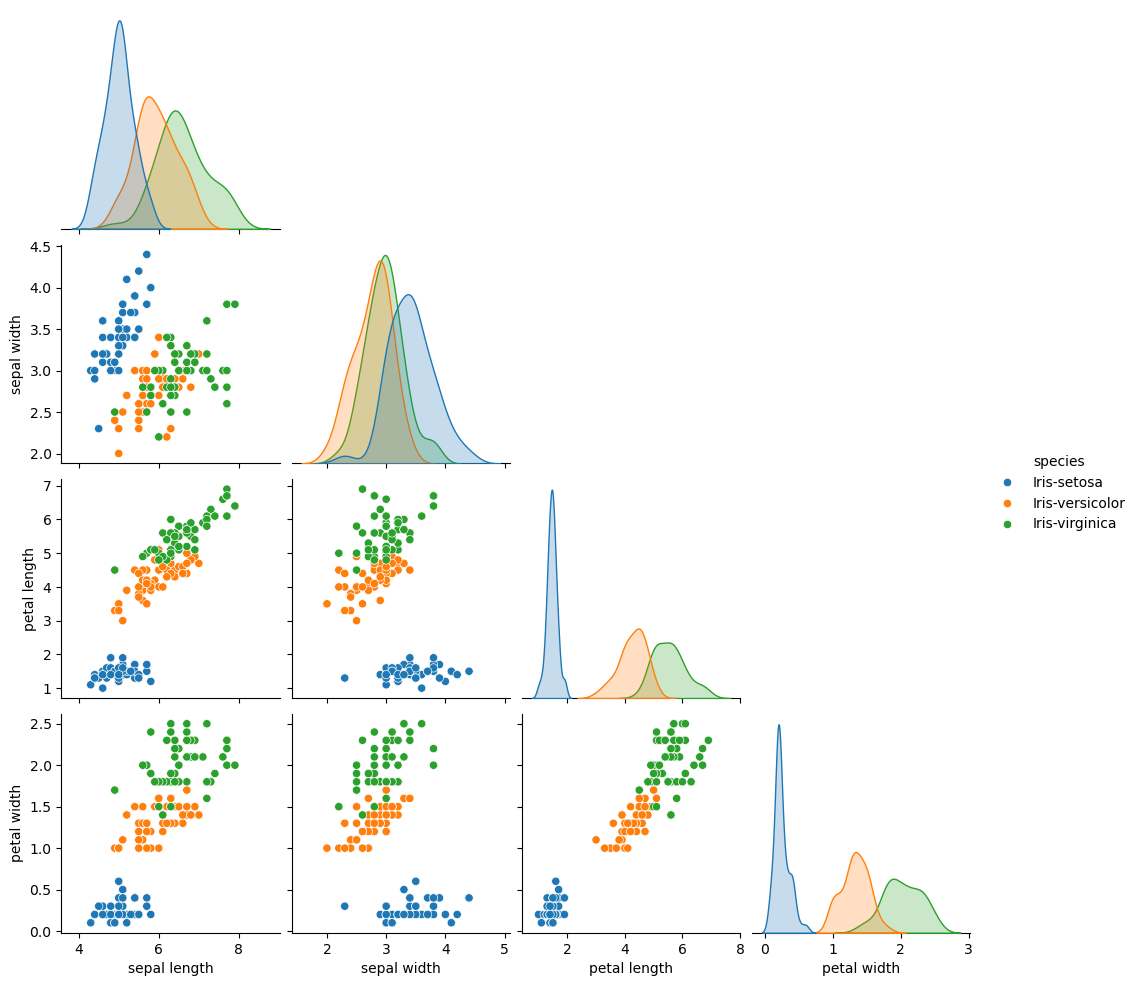

In [44]:
g = sns.pairplot(iris, hue='species', corner=True)

Oh, that's nice. 

It jumps out at me that the setosa is pretty different from the other two. The versicolor and the virginica are more similar, but there is a clear division between the two (except in the sepal length by sepal width facet). That we can see these patterns with our eyes suggests a model should work well. 

## Scikit Learn

We begin by preparing our data. We want a testing and a training dataset. We also need to convert our data from pandas to numpy arrays. scikit does not work with DataFrames. [This is because the numpy arrays are better for difficult numerical calculations, which some models require.] 

In [45]:
iris.shape

(150, 5)

In [46]:
# Keep 10 random observations to test. 
# The random_state ensures that we get the same 10 random observations each time.
test_data = iris.sample(10, random_state=5)

# The species data
y_test_df = test_data['species']

# The characteristics data
X_test_df = test_data.drop('species', axis = 1)

X_test_df

,sepal length,sepal width,petal length,petal width
82,5.8,2.7,3.9,1.2
134,6.1,2.6,5.6,1.4
114,5.8,2.8,5.1,2.4
42,4.4,3.2,1.3,0.2
109,7.2,3.6,6.1,2.5
57,4.9,2.4,3.3,1.0
1,4.9,3.0,1.4,0.2
70,5.9,3.2,4.8,1.8
25,5.0,3.0,1.6,0.2
84,5.4,3.0,4.5,1.5


In [47]:
# Convert the DataFrames to numpy arrays
y_test = y_test_df.to_numpy()
X_test = X_test_df.to_numpy()

X_test

array([[5.8, 2.7, 3.9, 1.2],
       [6.1, 2.6, 5.6, 1.4],
       [5.8, 2.8, 5.1, 2.4],
       [4.4, 3.2, 1.3, 0.2],
       [7.2, 3.6, 6.1, 2.5],
       [4.9, 2.4, 3.3, 1. ],
       [4.9, 3. , 1.4, 0.2],
       [5.9, 3.2, 4.8, 1.8],
       [5. , 3. , 1.6, 0.2],
       [5.4, 3. , 4.5, 1.5]])

In [48]:
# Do the same thing, but to the rest of the data --- the training data
# First, drop the testing observation. 
train_data = iris.drop(test_data.index)

y_train = train_data['species'].to_numpy()
X_train = train_data.drop('species', axis=1).to_numpy()

train_data.shape

(140, 5)

### Construct and fit the model

We are going to use a logistic regression model, which implements a [multinomial logistic regression](https://en.wikipedia.org/wiki/Multinomial_logistic_regression). There are many different types of models. In a machine learning class, you would try several models and choose the one that works best. Here, we are going to just use one model.

The logistic regression model has parameters $\beta$ for each characteristic and each species. $\beta_{pw,set}$ is the coefficient on petal width for the setosa. We have 4 characteristics and 3 species, so we have 12 parameters. The parameters and the characteristics determine a probability that an observation is a species.  

$$\text{pr}(set, i) = \text{logit}(\beta_{pw, set}pw_i + \beta_{pl, set}pl_i + \beta_{sw, set}sw_i+\beta_{sl,set}sl_i)$$
$$\text{pr}(ver, i) = \text{logit}(\beta_{pw, ver}pw_i + \beta_{pl, ver}pl_i + \beta_{sw,ver}sw_i+\beta_{sl,ver}sl_i)$$
$$\text{pr}(vir, i) = \text{logit}(\beta_{pw, vir}pw_i + \beta_{pl, vir}pl_i + \beta_{sw, vir}sw_i+\beta_{sl,vir}sl_i)$$

For an observation $i$, the species with the highest probability score is chosen. 

We use the training data to find the $\beta$s that make the model species prediction the best. This is technical process you would learn about in an advanced econometrics course or machine learning course. We will let scikit learn handle it for us. 

For such a complicated set up, the code is very short!

In [49]:
clf = LogisticRegression(random_state=0).fit(X_train, y_train)
type(clf)

sklearn.linear_model._logistic.LogisticRegression

The `LogisticRegression` object uses the `.fit()` method and the training data to find the $\beta$s. The random_state option sets the random number generator seed so that we all get the same answer.  

'clf' is an object with many attributes and methods. Let's see the $\beta$s.

In [50]:
clf.coef_

array([[-0.4552524 ,  0.91745799, -2.43448982, -1.04957421],
       [ 0.63549945, -0.43578385, -0.19511938, -1.01784518],
       [-0.18024705, -0.48167414,  2.62960921,  2.0674194 ]])

Each row is a set of $\beta$s for one species. 

We use the `predict()` method and the test data to see how well the model performs on data that was not used to estimate the $\beta$s. 

In [51]:
y_pred = clf.predict(X_test)

How do the predictions compare to the test data?

In [52]:
data = [list(row) for row in zip(y_test.tolist(), y_pred.tolist())]
compare = pd.DataFrame(data, columns=['Actual','Predicted'])
compare['Correct'] = (compare['Actual']==compare['Predicted'])
compare

,Actual,Predicted,Correct
0,Iris-versicolor,Iris-versicolor,True
1,Iris-virginica,Iris-virginica,True
2,Iris-virginica,Iris-virginica,True
3,Iris-setosa,Iris-setosa,True
4,Iris-virginica,Iris-virginica,True
5,Iris-versicolor,Iris-versicolor,True
6,Iris-setosa,Iris-setosa,True
7,Iris-versicolor,Iris-virginica,False
8,Iris-setosa,Iris-setosa,True
9,Iris-versicolor,Iris-versicolor,True


We missed once, getting 9/10 correct. We can use the `.score()` method, and the test data, to find the fraction of observations in the test data that the model predicted correctly. 

In [53]:
clf.score(X_test, y_test) # correct predict 90% of the time

0.9

To recap: 

0. Preliminary checks of data. Look for patterns.
1. Split data into test and train datasets.
2. Fit the model to the train dataset.
3. Evaluate the model using the test dataset.

If the model does well predicting in the test data, the model is ready to use. If the model does not do well, you would try a different model or modify the current model (this is called model *tuning*).  

In [54]:
# If the model doesnt fit well, you might want to change the model or add complexity, reduce features, etc. That is called model tuning.

## Practice: Predicting medical conditions

Let's look at another classic ML dataset. The 'diabetes.csv' file has data on characteristics of people and whether they have diabetes. The dataset is available at [kaggle.com](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database). It is originally from the National Institute of Diabetes and Digestive and Kidney Diseases and was used to build a model that predicts diabetes outcomes conditional on the person's observed characteristics. 

Our goal is to use the characteristics of the people in the dataset to predict diabetes outcomes. 

1. Load the 'diabetes.csv' file. Drop the variable 'DiabetesPedigreeFunction'. (We are doing this for a technical reason.)
2. How many characteristics ("features") are there? I do not know what many of the characteristics are, but they are defined on the dataset webpage. 
3. What values can `Outcome` (the "class" variable) take in the data set?  

In [55]:
diab = pd.read_csv('data/diabetes.csv')
diab.drop('DiabetesPedigreeFunction', axis=1, inplace=True)
diab.shape # 7 features and 1 classification

(768, 8)

4. Try a facet plot, setting hue to be `Outcome`. There are enough characteristics in this dataset that this is getting absurd. We can see how things get harder the more characteristics we have. 

   Do you see any patterns?

In [56]:
diab.Outcome.value_counts() # 500 people do not have diabetes, 268 do

Outcome
0    500
1    268
Name: count, dtype: int64

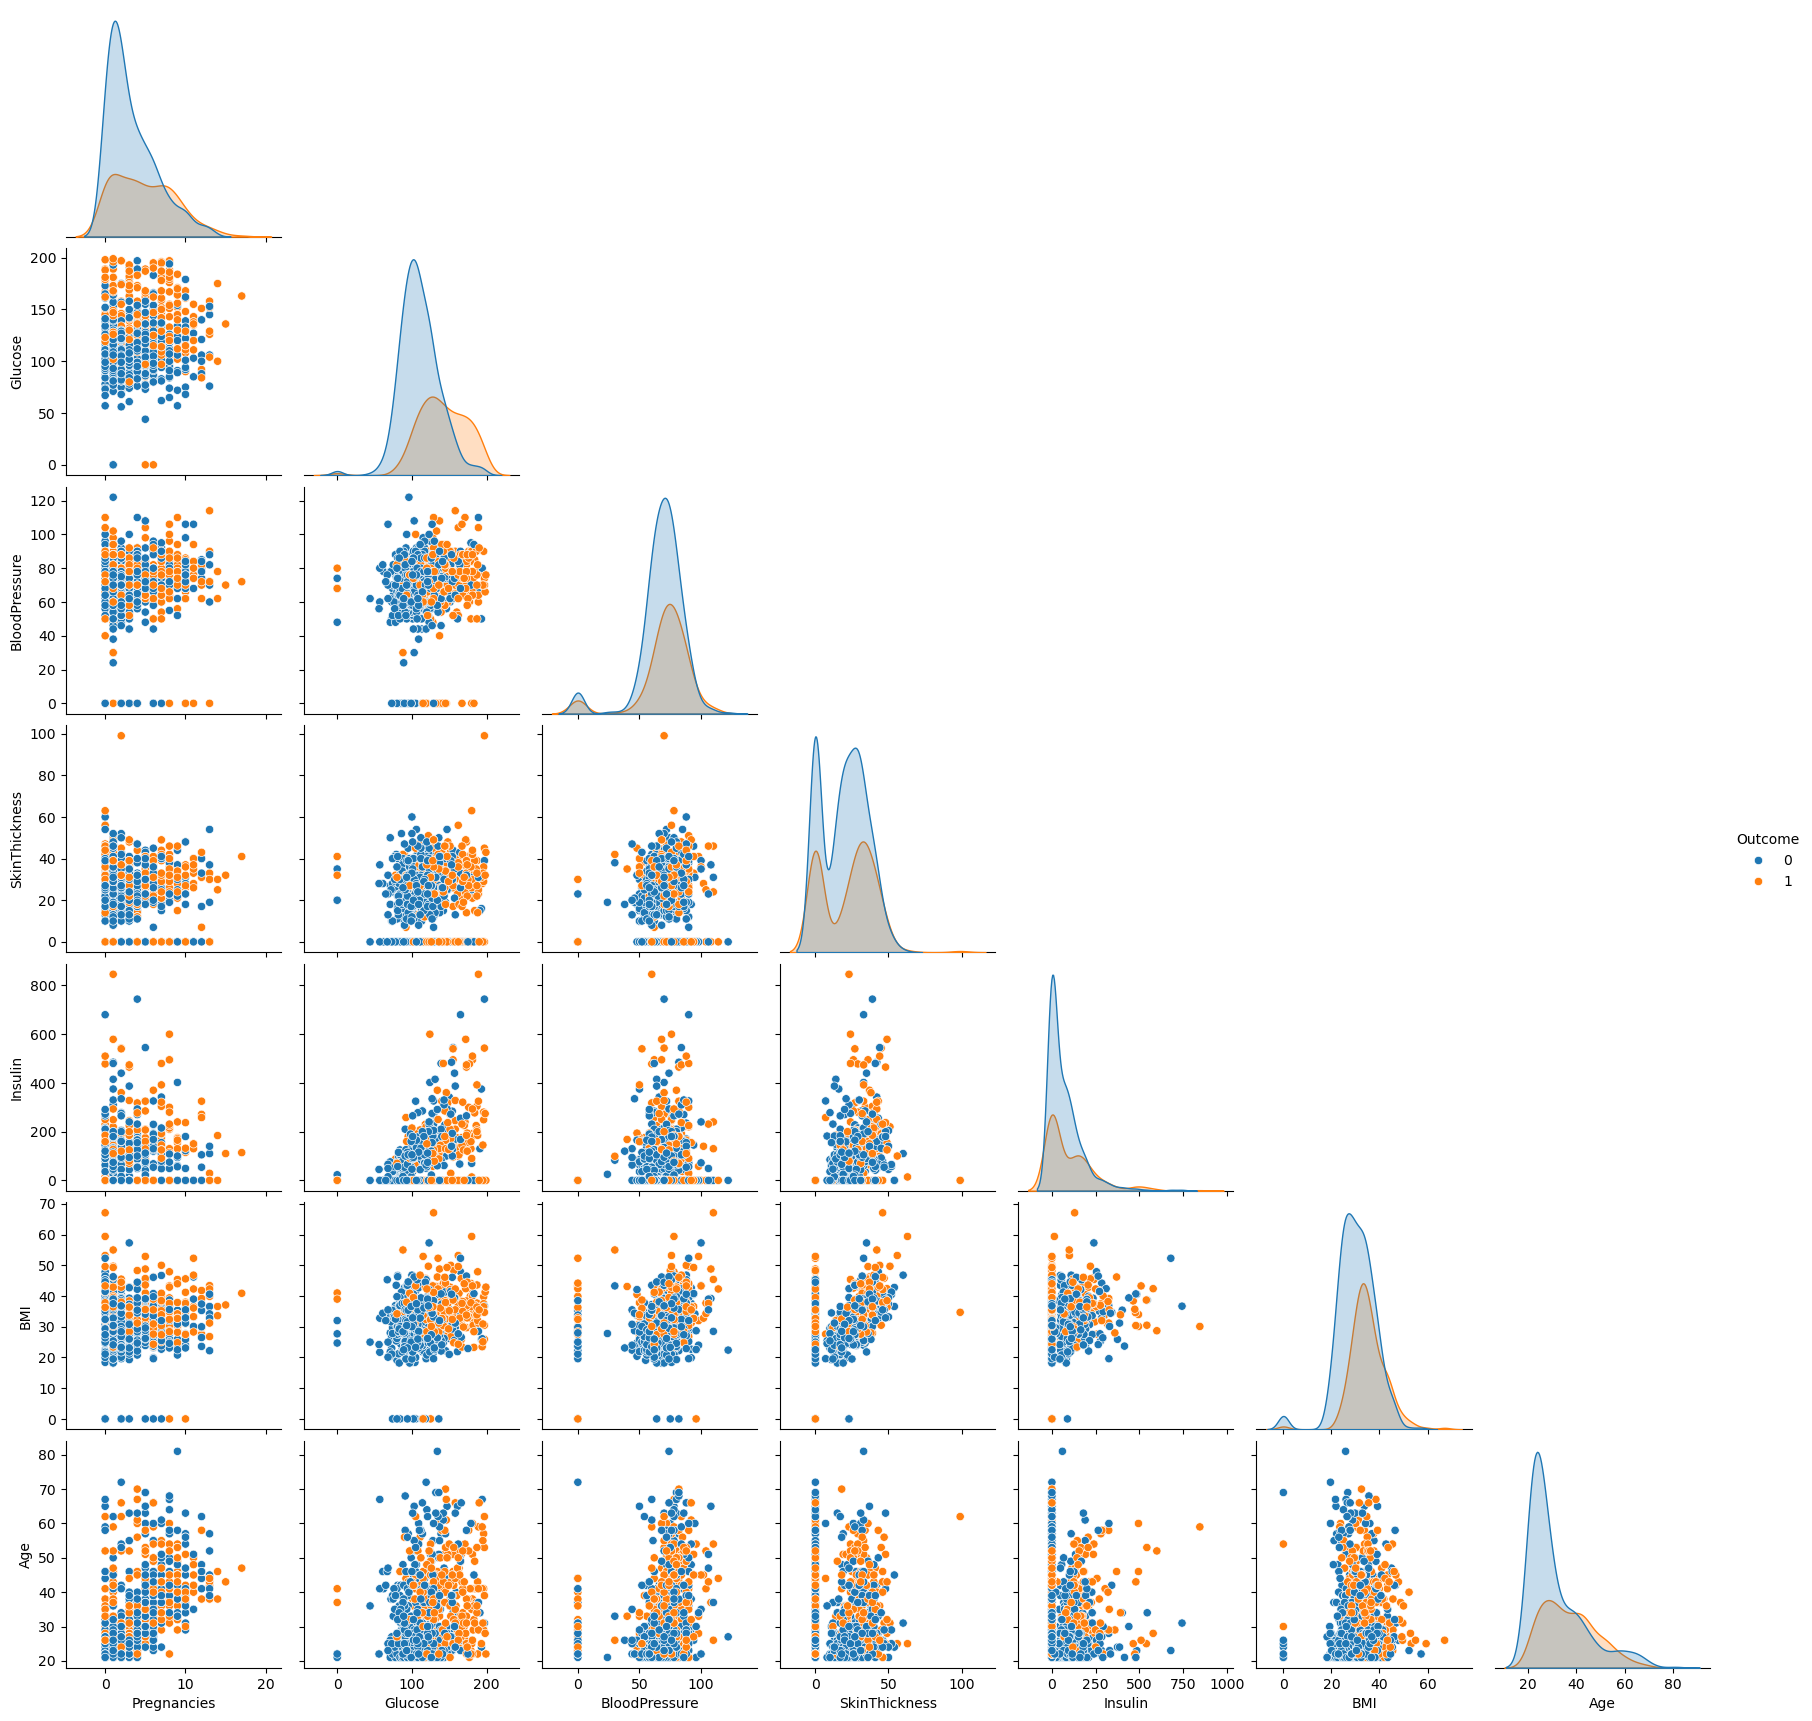

In [57]:
facet = sns.pairplot(diab, hue='Outcome', corner=True)

5. Break up the data into testing and training datasets. We did it manually before. Now, let's do it the easy way. scikit gives us the `train_test_split()` method which takes a dataset and breaks it up for us. Import the method using

```python
from sklearn.model_selection import train_test_split
```

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
                                                    diab.drop('Outcome', axis=1),
                                                    diab['Outcome'], 
                                                    test_size=0.20,
                                                    random_state=12)

6. The syntax for the method is below. Replace `X_data` with a DataFrame that only contains the features. Replace the `y_data` with a Series (one column) that only holds the outcome data.


* `test_size` is the size of the testing dataset: 20 percent of the observations are used for testing and 80 percent are used for training. Leave it set to 0.20 for now.
   
   
* `random_state` sets the seed for the random number generator. We are randomly assigning 20 percent of the observations to the test dataset. Setting the state ensures that we all split our dataset the same way. Leave it set to 12 for now.  

```python 
X_train, X_test, y_train, y_test = train_test_split(
                                                    X_data, 
                                                    y_data, 
                                                    test_size=0.20,
                                                    random_state=12)
```

Now go ahead and split your data into testing and training datasets. 

7. Fit the model to your training data. 

```python
diab_clf = LogisticRegression(random_state=0).fit(X_train, y_train)
```

   Leave the `random_state=0` so we all get the same answer. Take a look at the coefficients. 

8. How well does the model predict the test data? Use the `.score()` method and the test data to check. 

In [62]:
diab_clf = LogisticRegression(random_state=0).fit(X_train, y_train)
diab_clf.coef_


array([[ 1.09693896e-01,  3.61390312e-02, -1.37726842e-02,
        -1.61987158e-03,  3.35445645e-05,  8.58058166e-02,
         1.22970146e-02]])

In [63]:
diab_clf.score(X_test, y_test)

0.8051948051948052

Is this a good score? It is not as good as the iris model, but 80 percent doesn't seem terrible. If we really wanted to figure this out, we would try different models, experiment with different sets of characteristics and dig deeper into the data.  

Our goal today was just to get a sense of what all this machine learning talk is about. 

Let's check one more thing. In "predicting" the testing data, what kind of mistakes did we make? Did we predict diabetes when the patient did not have diabetes? Did we predict no-diabetes when the patient did have diabetes?

We can use the *confusion matrix* to sort this out. 

  9. Compute the predicted outcomes from our testing data. If you called the results object from fitting the regression `diab_clf` then 
  ```python
y_pred = diab_clf.predict(X_test)
``` 
would get you the predicted diabetes outcomes for each patient in the testing dataset.

In [66]:
from sklearn.metrics import confusion_matrix
y_pred = diab_clf.predict(X_test)
mat = confusion_matrix(y_test, y_pred, normalize='all')
mat

array([[0.58441558, 0.05844156],
       [0.13636364, 0.22077922]])

10. We compute the confusion matrix with

```python
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(y_test, y_pred, normalize='all')
```

The rows of the matrix are the truth and the columns are the predictions. The value in each cell is the share of the observations. 

|    |Prediction True | Prediction  False |
|----|-----|-------|
|Data True |.58441558|.05844156|
|Data False|.13636364|.22077922|

Looks like our "false positive" rate (the lower left cell) is higher than our "false negative" rate (the upper right cell). 

*Try on your own:* What characteristics do patients with "false positives" have?

## Dimension Reduction with Principal Component Analysis

In some applications, your feature vector `X` contains many features, only some of which are useful/necessary in explaining `y`.

One approach to this problem is to pre-process the data by performing *dimension reduction* on the high-dimensional `X`. The goal is to preserve the important variation in the original `X` data while reducing the number of features. Let's return to the iris data and explore a common dimension reduction technique: **Principal Component Analysis (PCA)**.

We'll use scikit learn's `PCA()`. Without any inputs, this will generate four principal components (equal to the number of features in the data). This creates a new object, which we will apply the `.fit_transform()` function. This will first fit the model and transform the feature data to the new coordinate system.

In [ ]:
species_codes = {'Iris-setosa':'0','Iris-versicolor':'1', 'Iris-virginica':'2'}
iris['species'] = iris['species'].replace(species_codes).astype(int)
iris.head(2)

,sepal length,sepal width,petal length,petal width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0


In [ ]:
# Separate features X and target y
X = iris.drop('species',axis=1)
y = iris['species']
# Create a PCA object
pca = PCA()
# Fit the PCA model to the data AND transform the data to the new coordinate system
X_pca = pca.fit_transform(X)
pd.DataFrame(X_pca, columns=['First principal component', 'Second principal component', 'Third principal component', 'Fourth principal component']).head(2)

,First principal component,Second principal component,Third principal component,Fourth principal component
0,-2.684207,0.326607,-0.021512,0.001006
1,-2.715391,-0.169557,-0.203521,0.099602


We now have four completely new `X` variables: principal components. How much of the variance in the *original data* do the four principal components explain? Our `pca` object also contains this information, and we can access this by applying `.explained_variance_ratio_`

In [ ]:
explained_variance=pca.explained_variance_ratio_
explained_variance

array([0.92461621, 0.05301557, 0.01718514, 0.00518309])

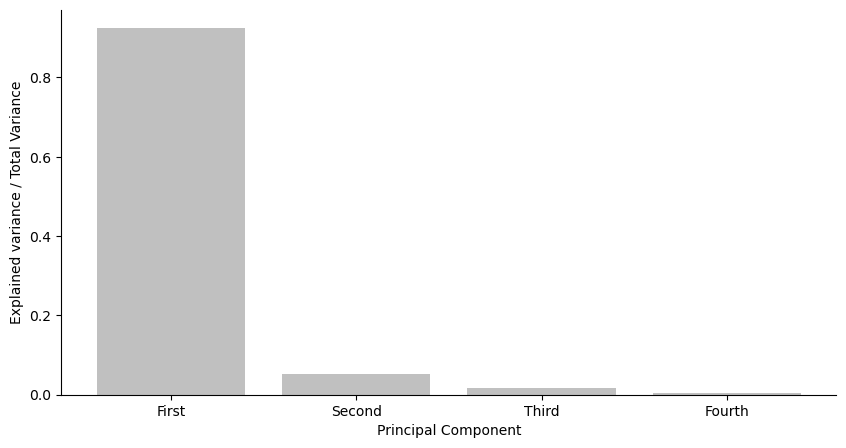

In [ ]:
fig, ax = plt.subplots(figsize=(10,5)) 
ax.bar(range(4), explained_variance, color='silver')
ax.set_ylabel('Explained variance / Total Variance')
ax.set_xlabel('Principal Component')
ax.set_xticks(ticks=[0,1,2,3])
ax.set_xticklabels(['First', 'Second', 'Third', 'Fourth'])
sns.despine(ax=ax)

The principal components are ordered based on how much of the variance in the original data they explain.  As we can see, 92.5% of total variance in the original four features can be explained by just the first principal component!

Let's keep the first two principal components, which together explain 97.8% of the variance.

## Classification using a simple k-nearest neighbors (KNN) algorithm

Can the species be separated only by the first two principal components? First, let's plot the data on the first two principal components.

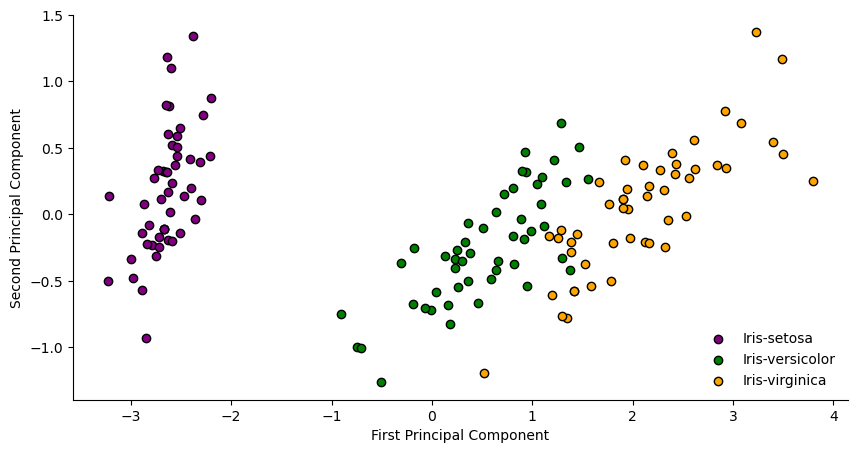

In [ ]:
fig, ax = plt.subplots(figsize=(10,5)) 

labels = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
colors = ['purple','green','orange']

for i in range(len(np.unique(y))):
    ix = np.where(y == i)
    ax.scatter(X_pca[ix, 0], X_pca[ix, 1], c=colors[i], label=labels[i], edgecolor='k')
    
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

sns.despine(ax=ax)
plt.legend(frameon=False)
plt.show()

Setosa is separable on the first principal component alone, while the versicolor and virginica are not quite as easy to separate.

Let's consider a very simple nonlinear classification algorithm: the **k-nearest neighbors (KNN) algorithm**. We choose a positive integer $k>0$ and predict the species for each data point based on which is the most common species among the $k$ nearest neighbors.

We'll re-run the `PCA()` with an argument of `n_components=2` to keep the first two principal components. Then, we'll fit and transform the data on these two components and apply the KNN classifier with the parameter $k=9$.

\[Note that I will use all the data instead of splitting the data into training and testing this time. We are now evaluating the *in-sample fit*.\]

In [ ]:
# Get the first two principal components
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X)
# Fit a knn with k=9
knn_pca = KNeighborsClassifier(9)
knn_pca.fit(X_pca2,y)
# Get the score
print("In-sample score:",knn_pca.score(X_pca2,y))

In-sample score: 0.9733333333333334


Let's get the confusion matrix.

In [ ]:
# Get the confusion matrix
pd.DataFrame(confusion_matrix(y, knn_pca.predict(X_pca2)), columns = ['Iris-setosa','Iris-versicolor', 'Iris-virginica'],
            index = ['Iris-setosa','Iris-versicolor', 'Iris-virginica'])

,Iris-setosa,Iris-versicolor,Iris-virginica
Iris-setosa,50,0,0
Iris-versicolor,0,47,3
Iris-virginica,0,1,49


Unsurprisingly, all of the setosa observations are correctly classified, while there is some misclassification of versicolor and virginica.

If we were to use this classifier on a test sample of flowers, what would be the classification rule? With two principal components, it is easy to visualize the classifier in two dimensions.

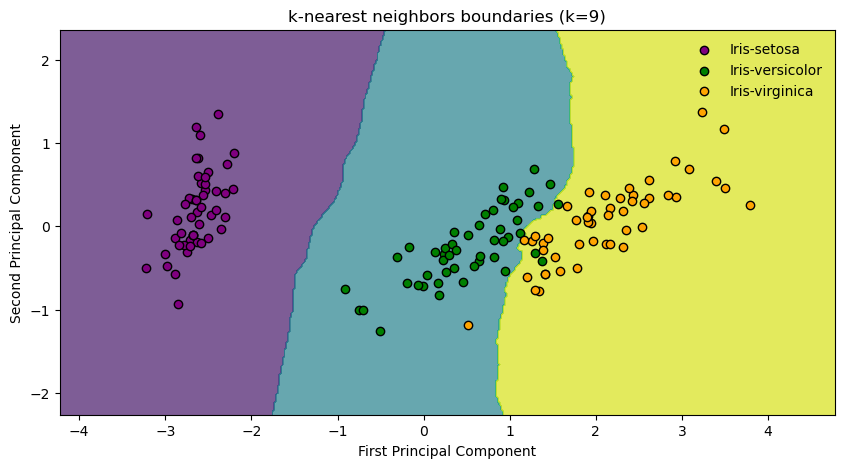

In [ ]:
# Visualize KNN predictions
fig, ax = plt.subplots(figsize=(10,5)) 

# Creating decision boundaries using a meshgrid
x_min, x_max = X_pca2[:, 0].min() - 1, X_pca2[:, 0].max() + 1
y_min, y_max = X_pca2[:, 1].min() - 1, X_pca2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting decision boundaries
plt.contourf(xx, yy, Z, alpha=0.7)

# Plot the values
for i in range(len(np.unique(y))):
    ix = np.where(y == i)
    ax.scatter(X_pca[ix, 0], X_pca[ix, 1], c=colors[i], label=labels[i], edgecolor='k')

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('k-nearest neighbors boundaries (k=9)')
plt.legend(frameon=False)
plt.show()

### Practice

1. Use `train_test_split` to create training and testing samples of the `iris` dataset, with 80% of the sample in the training set.

2. Fit a KNN algorithm on the training set, and calculate the score in the testing set. How well does the model perform? What do you think out-of-sample fit *means* in a KNN algorithm?

3. Redo the exercise, but base the KNN algorithm *only* on sepal width and length. What happens to the prediction? Why?